In [31]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [32]:
# Create a State
class BatsmanState(TypedDict):
    runs : int 
    balls : int
    fours : int
    sixes : int
    strikerate : float
    runs_per_boundary_percentage : float
    summary : str

In [33]:
def strikerate(state : BatsmanState) -> BatsmanState:
    total_run = state['runs']
    total_balls = state['balls']

    strike_rate = (total_run/total_balls)* 100

    return {'strikerate' : strike_rate}

In [34]:
def runsperboundary(state : BatsmanState) -> BatsmanState:
    total_runs = state['runs']
    rpb_percentage = (((state['fours'] * 4) + (state['sixes'] * 6))/ total_runs)* 100


    return {'runs_per_boundary_percentage': rpb_percentage}

In [35]:
def summary(state: BatsmanState):
    summary = f"""strike rate - {state['strikerate']} \n
    Runs Per Boundary Percentage - {state['runs_per_boundary_percentage']}"""

    return {'summary': summary}

In [36]:
# Create a Graph
graph = StateGraph(BatsmanState)

# Create a Node
graph.add_node('strikerate', strikerate)
graph.add_node('runsperboundary', runsperboundary)
graph.add_node('summary', summary)
# graph.add_node('bpb', bpb)

# Create edges
graph.add_edge(START, 'strikerate')
graph.add_edge(START, 'runsperboundary')


graph.add_edge('strikerate', 'summary')
graph.add_edge('runsperboundary', 'summary')
graph.add_edge('summary', END)


# Compile the Graph
workflow = graph.compile()

In [37]:
initial_state = {'runs': 124, 'balls': 54, 'fours': 10, 'sixes': 10}

final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 124, 'balls': 54, 'fours': 10, 'sixes': 10, 'strikerate': 229.62962962962962, 'runs_per_boundary_percentage': 80.64516129032258, 'summary': 'strike rate - 229.62962962962962 \n\n    Runs Per Boundary Percentage - 80.64516129032258'}


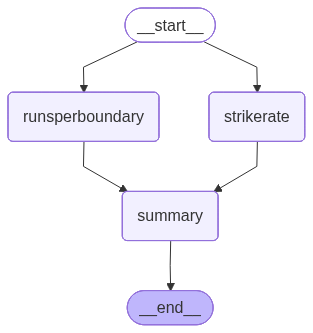

In [38]:
workflow